# Raman and infrared spectra

An experiment does not resolve a tensor. It resolves a **mode**: a frequency, an intensity,
and for Raman a depolarisation ratio. Getting there contracts three quantities with the
phonon eigendisplacement $z^\nu$ -- the way the polarizability changes when an atom moves,
the Born effective charges, and the modes themselves:

$$ R^{\nu}_{ij} = \sum_{a,k} \frac{\partial \chi_{ij}}{\partial \tau_{a,k}}\, z^{\nu}_{a,k},
\qquad
p^{\nu}_i = \sum_{a,k} Z^{*}_{a,ik}\, z^{\nu}_{a,k} $$

with the Raman activity built from the two Placzek invariants of $R^\nu$ and the infrared
activity from $|p^\nu|^2$. A mode is Raman-active if it modulates the polarizability and
infrared-active if it carries a dipole, and those are independent questions.

| | here | elsewhere |
|---|---|---|
| silicon's optical triplet | **519.20 cm⁻¹** | 520, measured |
| its infrared activity | **3.6e-31** | zero by symmetry |
| every mode of AlAs and silicon | | every digit `dynmat.x` prints |
| AlAs $d\varepsilon_{yz}/d\tau_x$ | **-3.118279** | -3.118310, a finite difference |

Silicon's line at 520 cm⁻¹ is the one every Raman spectrometer is calibrated on, and its
silence in the infrared is why silicon is transparent there. Both are symmetry statements
rather than fits.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")

alas = Calculator.from_file(CASES / "alas-raman-wedge.in", pseudo_dir=PSEUDO,
                            announce=False)
spectrum = alas.get_vibrational_spectrum()
print(spectrum.table())

# mode   [cm-1]    [THz]      IR          Raman   depol.fact
    1      1.82    0.0545    0.3576         0.0000    0.7500
    2      1.82    0.0545    0.3576         0.0000    0.7500
    3      1.82    0.0545    0.3576         0.0000    0.7500
    4    353.25   10.5902    5.9262       446.8854    0.7500
    5    353.25   10.5902    5.9262       446.8854    0.7500
    6    353.25   10.5902    5.9262       446.8854    0.7500


One call, and inside it the self-consistent field response, the self-consistent displacement
response, the Raman tensors, the Born effective charges and the dynamical matrix. The two
responses are the expensive part and the displacement one is shared between the Raman
tensors and the phonons, so the whole spectrum costs little more than the phonons alone.

The k-set is the **irreducible wedge**, eight points where the closed grid has sixty-four.
A Raman tensor has three free cartesian labels, so a sum over a wedge is incomplete in all
three and the point group has to complete it; with that done the two agree to 3.3e-9, which
is what their two self-consistent runs agree to rather than a property of the symmetriser.

AlAs is polar and is active in both channels. Silicon is the interesting case, and both of
its statements are pure symmetry: the optical triplet is diamond's Raman-active $T_{2g}$,
and it is infrared **silent**, because an operation of the group carries one silicon onto
the other and so gives them the same $Z^*$ -- the optical mode moves them against each
other, so it carries no dipole at all.

In [2]:
silicon = Calculator.from_file(CASES / "si-epsilon-unshifted.in", pseudo_dir=PSEUDO,
                               announce=False)
si = silicon.get_vibrational_spectrum()
print(si.table())
print("\nsilicon T_2g   %.1f cm^-1   (measured 520)" % si.frequencies[-1])
print("infrared activity of the optical triplet   %.2e"
      % np.abs(si.infrared[3:]).max())

# mode   [cm-1]    [THz]      IR          Raman   depol.fact
    1      4.32    0.1295    2.3510         0.0000    0.5899
    2      4.32    0.1295    2.3510         0.0000    0.3964
    3      4.32    0.1295    2.3510         0.0000    0.5132
    4    519.20   15.5654    0.0000      9815.5634    0.7500
    5    519.20   15.5654    0.0000      9815.5634    0.7500
    6    519.20   15.5654    0.0000      9815.5634    0.7500

silicon T_2g   519.2 cm^-1   (measured 520)
infrared activity of the optical triplet   3.61e-31


## The spectra a spectrometer would record

Each mode a Lorentzian of its activity on a shared axis. The width is instrumental rather
than physical, which is why it is a parameter.

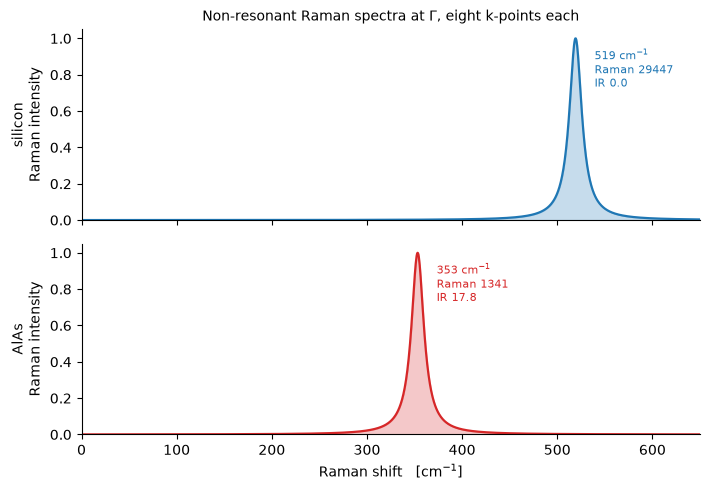

In [3]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(7.2, 5.0), sharex=True)
grid = np.linspace(0.0, 650.0, 1400)

for axis, data, name, colour in ((top, si, "silicon", "#1f77b4"),
                                 (bottom, spectrum, "AlAs", "#d62728")):
    data.plot(ax=axis, grid=grid, color=colour, lw=1.6)
    for frequency, raman, infrared in data.by_manifold():
        if frequency < 20.0:
            continue
        axis.annotate("%.0f cm$^{-1}$\nRaman %.0f\nIR %.1f" % (frequency, raman, infrared),
                      xy=(frequency + 20.0, 0.70 * axis.get_ylim()[1]), fontsize=8,
                      color=colour)
    axis.set_ylabel("%s\nRaman intensity" % name)
    axis.set_title("")
    axis.spines[["top", "right"]].set_visible(False)

top.set_xlabel("")
bottom.set_xlabel("Raman shift   [cm$^{-1}$]")
top.set_title("Non-resonant Raman spectra at $\\Gamma$, eight k-points each", fontsize=10)
fig.tight_layout()

One line each, at very different places, and only AlAs has anything in the infrared.

## How it works: the Raman tensor is the slope of the dielectric tensor

The quantity the spectrum contracts is

$$ \frac{\partial \varepsilon_{ij}}{\partial \tau_{a,k}}, $$

a third derivative of the energy -- two fields and a displacement. It comes out the same way
notebook 21's strain derivative does: the second-order energy is stationary in the
first-order wavefunctions, so it can be differentiated with them held fixed, and everything
it needs already exists at that point. The displacement response is what the dynamical
matrix of notebook 20 solves for, the field response is notebook 19's.

Two things make it unusual. A **gradient-corrected functional** works here, where `ph.x`
stops on "third order derivatives not implemented with GGA". And **the reference had to be
built from scratch**: the vendored `ph.x` does not reproduce QE's own committed example for
this quantity -- -1.868 against the released -0.785 -- and fails its own internal check,
printing a finite-difference dielectric constant of -0.288 beside its analytic 8.8143 where
the older release has 8.8116 beside 8.8147. So the comparison is against a finite difference
of $\varepsilon$ over re-converged displaced cells, computed here: **-3.118279** against
**-3.118310**.

In [4]:
raman = alas.get_raman_tensors()
scale = np.abs(raman.raman).max()
forbidden = max(abs(raman.raman[a, c, i, j]) for a in range(raman.raman.shape[0])
                for c in range(3) for i in range(3) for j in range(3) if len({c, i, j}) != 3)

print("d(eps)/d(tau) of AlAs, one independent component in -43m:")
print("   Al displaced along x, eps_yz   %10.6f" % raman.raman[0, 0, 1, 2])
print("   As displaced along x, eps_yz   %10.6f" % raman.raman[1, 0, 1, 2])
print("\nlargest entry the point group forbids   %.1e of the scale" % (forbidden / scale))
print("translational sum rule                  %.1e of the scale"
      % raman.sum_rule_relative)

d(eps)/d(tau) of AlAs, one independent component in -43m:
   Al displaced along x, eps_yz    -3.118279
   As displaced along x, eps_yz     3.119166

largest entry the point group forbids   3.6e-16 of the scale
translational sum rule                  2.8e-04 of the scale


AlAs is $\bar 4 3m$, where a rank-3 tensor has exactly **one** independent component: the
entries with all three indices different are equal and everything else is zero. Nothing
imposed those zeros -- they are what the calculation returned. The second check is the
**translational sum rule**: moving every atom by the same vector translates the crystal,
which cannot change $\varepsilon$, so the tensors sum to zero over atoms. It is the acoustic
sum rule of notebook 20 one derivative up, and like it, it is reported rather than imposed.

## One rule about reading these numbers

A degenerate multiplet has no preferred basis: any orthogonal mixing of its members is as
good an answer, and two eigensolvers will return different ones. Both Placzek invariants are
**quadratic** in the mode's Raman tensor, so the multiplet's *sum* of activities survives
that mixing and its individual entries do not. A degenerate multiplet is comparable only as
a sum -- between two codes and between two runs.

That is not a caveat that had to be looked for. Silicon's acoustic triplet in the table
above carries depolarisation ratios of 0.5899, 0.3964 and 0.5132; `dynmat.x`,
re-diagonalising the very same matrix, gives 0.5873, 0.2446 and 0.7264; and an earlier run
of this code gave 0.3544, 0.7163 and 0.4065. All three are the same physics, and the way to
know that is the column beside them, where all three read an activity of 0.0000.

## What is not here

**$\chi^{(2)}$ and the electro-optic tensor**, which govern second harmonic generation, are
the same functional differentiated along a third **field** rather than along a displacement,
and they are refused by name: the field enters this calculation only through the source
term, so one piece of the expression has nothing to build it from. The size of what is
missing is a measurement rather than an estimate, because the displacement derivative has
the same kind of term and it *is* computed here -- zeroing it moves
$d\varepsilon_{yz}/d\tau$ from -3.118279 to -1.809983, which is **42%** of the answer. And
nothing catches its absence by symmetry: without that term the tensor still vanishes
identically in silicon, still comes out exactly zincblende in AlAs, and is still symmetric
under every permutation of its three labels to 2.5e-13. Symmetry checks constrain the form
of a tensor of this rank and say nothing about its size.

The **non-analytic LO-TO term** is not implemented either, so AlAs's optical triplet comes
out unsplit where a real measurement finds a TO/LO pair; its two ingredients, $Z^*$ and
$\varepsilon$, are both computed above.

---
The tests behind this notebook: `tests/regression/test_spectra.py`, which runs the vendored
`dynmat.x` on the same tensors and compares every mode it prints -- the one Quantum ESPRESSO
reference above second order that still works, because it is post-processing and never
touches the branch that computes them; `tests/regression/test_nonlinear.py`, which holds the
finite difference over re-converged displaced cells, the zincblende form, the sum rule, the
wedge against the closed grid, and the 42% measurement; and `tests/unit/test_spectra.py`,
which holds the Placzek invariants and the multiplet rule.